# Helmholtz equation

This notebook we will implement a PINN solver and benchmark for the [Helmholtz equation](https://en.wikipedia.org/wiki/Helmholtz_equation) in 2D which has the form 
$$
    \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} + k^2 u = f(x,y)
$$
in particular, for the benchmarking, we will need a closed-form solution, therefore (based on the grace of the internet), there is a well-known one in the case of
- $k=1$
- $f(x,y) =  -\pi^2 \sin(\pi x) \sin(4\pi y) - (4\pi)^2 \sin(\pi x) \sin(4 \pi y) + \sin(\pi x) \sin(4\pi y)$

posed on the spatial domain $(x,y) \in [-1,1] \times [-1,1]$ which subjected to the zero boundary condition meaning
$$
    u(-1,y) = u(1,y) = u(x,-1) = u(x,1) = 0
$$
we can derive that the analytical solution is of the form
$$
    u(x,y) = \sin(\pi x)\sin(4 \pi y)
$$

In [60]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.dont_write_bytecode = True
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
# Backend set up for neural networks
torch.cuda.empty_cache()
# Set seed
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_default_dtype(torch.float32)

# CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [62]:
# We will first implement the analytical solution function using PyTorch API since we will need the computation to be done on GPU if possible
def analytical_solution(x, y):
    return torch.sin(np.pi * x) * torch.sin(4 * np.pi * y)

In [63]:
# Defining the PINN model
"""
    Neural Network architecture for the PINN
"""
class NN(nn.Module):
    def __init__(self, hidden_layers=[20,20,20,20], activation="relu"):
        super().__init__()
        self.input_layer = nn.Linear(2, hidden_layers[0])
        self.activation = self._get_activation(activation)
        self.hidden = nn.ModuleList([nn.Linear(hidden_layers[i], hidden_layers[i+1]) for i in range(len(hidden_layers) - 1)])
        self.output = nn.Linear(hidden_layers[-1], 1)
        self.apply(self._initialize_weights)
    
    @staticmethod 
    def _get_activation(activation):
        if activation.lower() == "tanh":
            return nn.Tanh()
        elif activation.lower() == "relu":
            return nn.ReLU()
        else:
            return nn.ReLU()
        
    @staticmethod 
    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_normal_(module.weight)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0.0)
    
    def forward(self, x, y):
        input = torch.cat([x, y], dim=1)
        output = self.input_layer(input)
        for layer in self.hidden:
            output = self.activation(layer(output))
        output = self.output(output)
        return output


"""
    Helmholtz Equation PINN
"""
class HelmholtzPINN(nn.Module):
    def __init__(self, f, k=1, hidden_layers=[40,40,40,40], activation="tanh"):
        super().__init__()

        self.k = k
        self.f = f
        self.model = NN(hidden_layers, activation)   # Neural Network model
    
    def forward(self, x, y):
        return self.model(x,y)


    def predict(self, x, y):
        self.model.eval()
        with torch.no_grad():
            return self.model(x,y)
    
    def helmholtz_residual(self, x, y):
        """
        Helmholtz redisual 
        """
        # Create tensors that require gradients
        x = x.clone().detach().requires_grad_(True)
        y = y.clone().detach().requires_grad_(True)

        # Forward pass
        u = self.forward(x, y)

        # First derivatives
        u_x = torch.autograd.grad(
            u, x, 
            grad_outputs=torch.ones_like(u),
            create_graph=True,
            retain_graph=True
        )[0]
        
        u_y = torch.autograd.grad(
            u, y,
            grad_outputs=torch.ones_like(u),
            create_graph=True,
            retain_graph=True
        )[0]
        
        # Second derivative
        u_xx = torch.autograd.grad(
            u_x, x,
            grad_outputs=torch.ones_like(u_x),
            create_graph=True,
            retain_graph=True
        )[0]

        u_yy = torch.autograd.grad(
            u_y, y,
            grad_outputs=torch.ones_like(u_y),
            create_graph=True,
            retain_graph=True
        )[0]

        # Heat equation residual
        return u_xx + u_yy + self.k**2 * u - self.f(x,y)
    

In [64]:
"""
Parameters defining the problem
"""

# Wave number
k = 1

# Domain
x_bounds = [-1, 1]
y_bounds = [-1, 1]

def source_term(x,y):
    return( -np.pi**2 * torch.sin(np.pi * x) * torch.sin(4 * np.pi * y) 
            - (4 * np.pi)**2 * torch.sin(np.pi * x) * torch.sin(4 * np.pi * y) 
            + torch.sin(np.pi * x) * torch.sin(4 * np.pi * y))


# Boundary condtion
def zero_boundary(input):
    return 0 * input # For the LOLs

boundary_conditions = {
    "boundary_left"     : zero_boundary,
    "boundary_right"    : zero_boundary,
    "boundary_top"      : zero_boundary,
    "boundary_bottom"   : zero_boundary,
}

In [65]:
# Initialize solving PINN
%autoreload 2
pinn = HelmholtzPINN(f=source_term, k=k, 
                    hidden_layers=[128,128,128,128,128], activation="tanh").to(device)

In [66]:
"""
Training with checkpointing
"""

def train(pinn, x_bounds, y_bounds, boundary_conditions, model_path,
        epochs=5000, lr=0.001,
        collocation_points=2000, boundary_points=3000, 
        print_interval=100):
    
    # Setting up the optimizer
    optimizer = optim.Adam(pinn.model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", patience=100, factor=0.5)

    # Getting the bounds
    x_min, x_max = x_bounds
    y_min, y_max = y_bounds

    # Loss history
    history = {
        "total_loss": [], 
        "residual_loss": [], 
        "boundary_loss": [],
        "mse": []
    }

    # Data of best model
    smallest_loss = float("inf")
    smallest_mse = float("inf")
    best_epoch = 0

    pinn.model.train()

    # Training loop
    for epoch in range(epochs):

        # Zero out the gradient in optimizer
        optimizer.zero_grad()
        
        # Sample and compute loss on collocation points (interior domain)
        x_collocations = torch.rand(collocation_points, 1, device=device) * (x_max - x_min) + x_min
        y_collocations = torch.rand(collocation_points, 1, device=device) * (y_max - y_min) + y_min

        residual = pinn.helmholtz_residual(x_collocations, y_collocations)
        residual_loss = torch.mean(residual**2)

        # Sample and compute loss on boundary condition points
        # Left boundary (x = x_min)
        y_left = torch.rand(boundary_points, 1, device=device) * (y_max - y_min) + y_min
        x_left = torch.ones_like(y_left) * x_min
        pred_left = pinn(x_left, y_left)
        true_left = boundary_conditions["boundary_left"](y_left)
        loss_left = torch.mean((pred_left - true_left)**2)
        
        # Right boundary (x = x_max)
        y_right = torch.rand(boundary_points, 1, device=device) * (y_max - y_min) + y_min
        x_right = torch.ones_like(y_right) * x_max
        pred_right = pinn(x_right, y_right)
        true_right = boundary_conditions["boundary_right"](y_right)
        loss_right = torch.mean((pred_right - true_right)**2)
        
        # Bottom boundary (y = y_min)
        x_bottom = torch.rand(boundary_points, 1, device=device) * (x_max - x_min) + x_min
        y_bottom = torch.ones_like(x_bottom) * y_min
        pred_bottom = pinn(x_bottom, y_bottom)
        true_bottom = boundary_conditions["boundary_bottom"](x_bottom)
        loss_bottom = torch.mean((pred_bottom - true_bottom)**2)
        
        # Top boundary (y = y_max)
        x_top = torch.rand(boundary_points, 1, device=device) * (x_max - x_min) + x_min
        y_top = torch.ones_like(x_top) * y_max
        pred_top = pinn(x_top, y_top)
        true_top = boundary_conditions["boundary_top"](x_top)
        loss_top = torch.mean((pred_top - true_top)**2)
        
        boundary_loss = loss_left + loss_right + loss_bottom + loss_top

        # Somwhat adaptive loss
        total_loss = 2* residual_loss + 10 *(loss_left + loss_right + loss_bottom + loss_top)

        # Calculate MSE
        mse = residual_loss + boundary_loss

        # Backpropagate and update
        total_loss.backward()
        
        # Gradient clipping to prevent instability
        torch.nn.utils.clip_grad_norm_(pinn.model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step(total_loss)

        # Store losses
        history["total_loss"].append(total_loss.item())
        history["residual_loss"].append(residual_loss.item())
        history["boundary_loss"].append(boundary_loss.item())
        history["mse"].append(mse.item())
        
        # Checkpoint the model states which has the lowest MSE
        if mse < smallest_mse:
            best_epoch = epoch
            smallest_mse = mse
            torch.save({
                "model": pinn.model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "losses": history,
                "best_epoch": best_epoch,
                "epoch": epoch,
                "k": pinn.k,
                "x_bounds": x_bounds,
                "y_bounds": y_bounds
            }, model_path)

        # Print progress
        if epoch % print_interval == 0:
            print(f"Epoch {epoch:4d}: Total Loss = {total_loss.item():.6f} | "
                  f"Residual = {residual_loss.item():.6f} | "
                  f"Boundary = {boundary_loss.item():.6f} | "
                  f"MSE = {mse.item():.6f}")
    
    # Print best model info
    print(f"\nBest model occurred at epoch {best_epoch}, with lowest MSE of {smallest_mse:.6f}")
    print(f"Model saved to: {model_path}")

    # Return history for optional visualization
    return history


"""
    Loading checkpoint
"""
def load_model(model_path, device="cpu", silent=True):

    # Load the checkpoint
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    checkpoint = torch.load(model_path, map_location=device)

    # Print some checkpoint data to console if we are not silent (a.k.a debugging)
    if not silent:
        print(f"Model loaded from epoch {checkpoint["epoch"]}")
        print(f"Best epoch: {checkpoint["best_epoch"]}")
        print(f"Wave number k: {checkpoint["k"]}")
    
    return checkpoint

In [67]:
model_path = "best-helmholtz-model.pth"
history = train(pinn, x_bounds=x_bounds, y_bounds=y_bounds, boundary_conditions=boundary_conditions, model_path=model_path,
                collocation_points=10000, boundary_points=12000,
                epochs=6001, print_interval=500)

Epoch    0: Total Loss = 13784.217773 | Residual = 6891.649414 | Boundary = 0.091912 | MSE = 6891.741211
Epoch  500: Total Loss = 635.746033 | Residual = 302.809753 | Boundary = 3.012650 | MSE = 305.822418
Epoch 1000: Total Loss = 55.454582 | Residual = 24.706497 | Boundary = 0.604159 | MSE = 25.310656
Epoch 1500: Total Loss = 9.470980 | Residual = 3.764280 | Boundary = 0.194242 | MSE = 3.958522
Epoch 2000: Total Loss = 3.433108 | Residual = 1.189762 | Boundary = 0.105359 | MSE = 1.295120
Epoch 2500: Total Loss = 1.998876 | Residual = 0.612662 | Boundary = 0.077355 | MSE = 0.690017
Epoch 3000: Total Loss = 1.580733 | Residual = 0.493144 | Boundary = 0.059445 | MSE = 0.552589
Epoch 3500: Total Loss = 1.440882 | Residual = 0.487381 | Boundary = 0.046612 | MSE = 0.533993
Epoch 4000: Total Loss = 0.984327 | Residual = 0.300537 | Boundary = 0.038325 | MSE = 0.338863
Epoch 4500: Total Loss = 0.799104 | Residual = 0.240861 | Boundary = 0.031738 | MSE = 0.272599
Epoch 5000: Total Loss = 0.7265

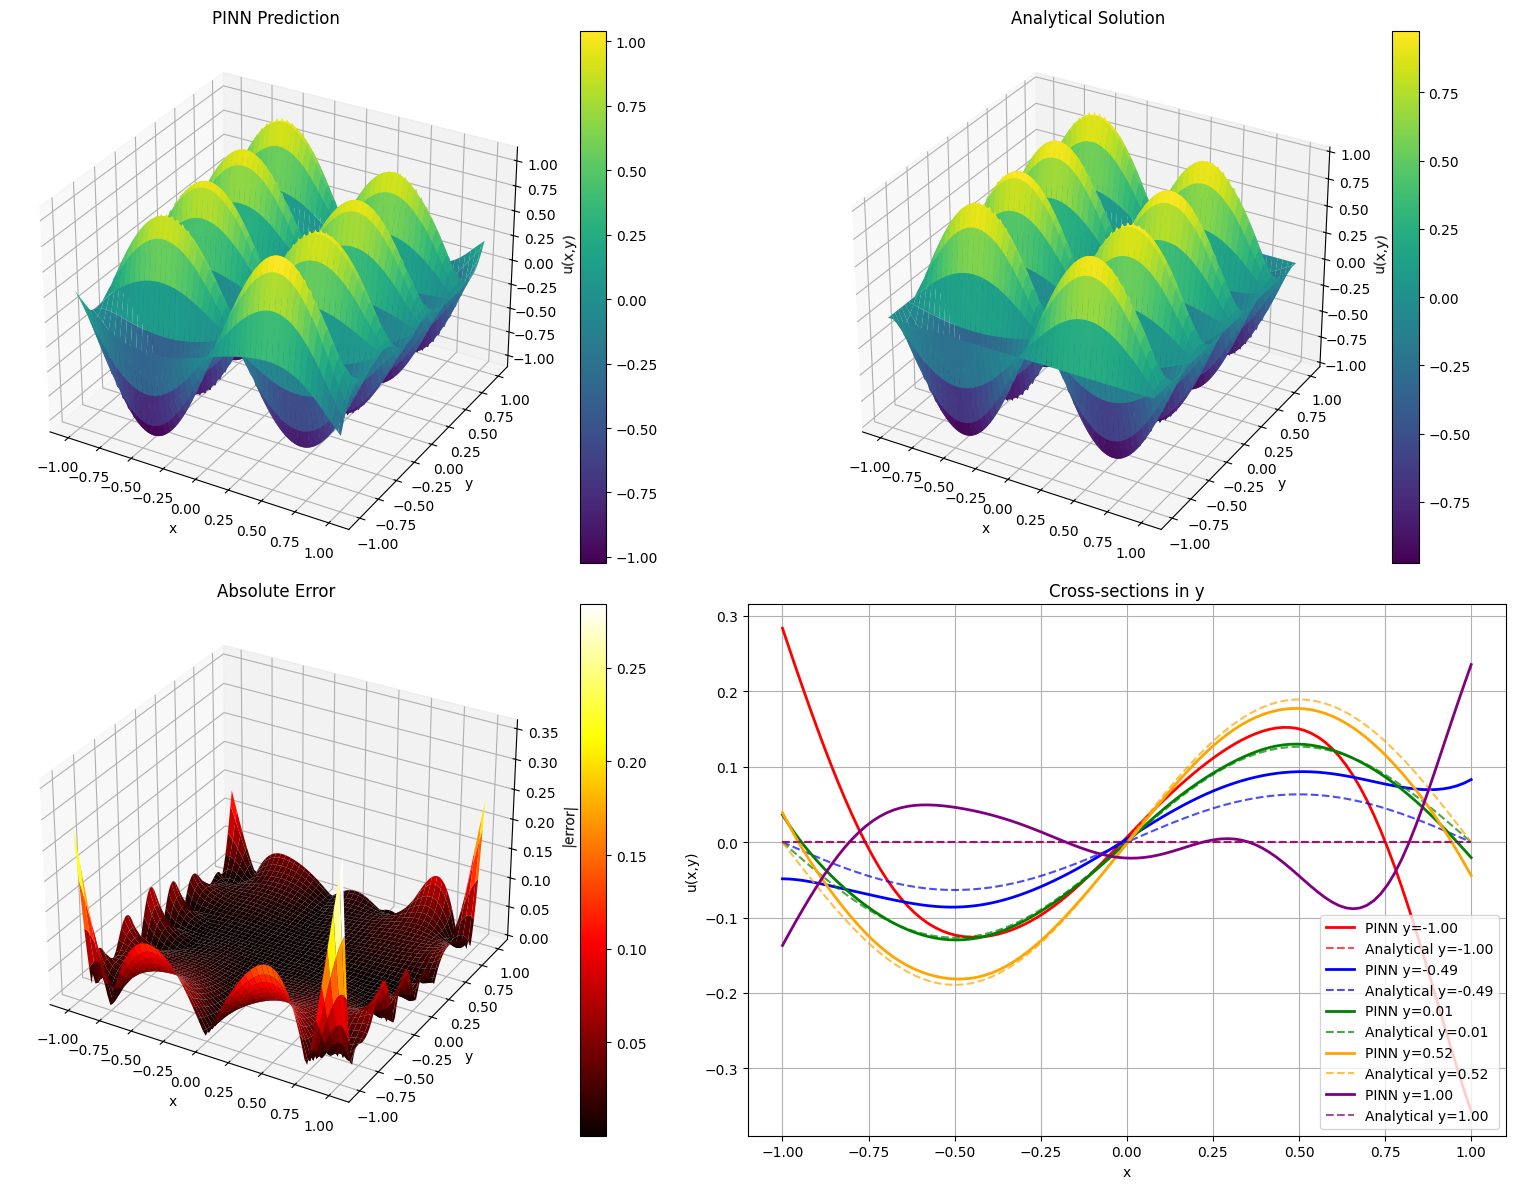

In [68]:
def benchmark(model_path=model_path, analytical_solution=analytical_solution, 
              x_bounds=x_bounds, y_bounds=y_bounds, 
              x_plot_pts=100, y_plot_pts=100):
    """
    Benchmark the trained model against analytical solution
    """
    
    # Load best model
    checkpoint = load_model(model_path, device=device)
    pinn.model.load_state_dict(checkpoint["model"])
    pinn.model.eval()
    
    # Setup domain
    x_min, x_max = x_bounds
    y_min, y_max = y_bounds
    
    # Create test grid
    x_test = torch.linspace(x_min, x_max, x_plot_pts, device=device)
    y_test = torch.linspace(y_min, y_max, y_plot_pts, device=device)
    X, Y = torch.meshgrid(x_test, y_test, indexing="ij")
    X_flat = X.reshape(-1, 1)
    Y_flat = Y.reshape(-1, 1)
    
    # Predictions
    with torch.no_grad():
        u_pred = pinn.predict(X_flat, Y_flat).reshape(x_plot_pts, y_plot_pts).cpu().numpy()
        u_analytical = analytical_solution(X, Y).cpu().numpy()
    
    # Calculate error
    error = np.abs(u_pred - u_analytical)
    
    # Convert to numpy for plotting
    X_np = X.cpu().numpy()
    Y_np = Y.cpu().numpy()
    
    # Performance visualization
    fig = plt.figure(figsize=(16, 12))
    
    # 1. PINN Prediction
    ax1 = fig.add_subplot(2, 2, 1, projection="3d")
    surf1 = ax1.plot_surface(X_np, Y_np, u_pred, cmap="viridis")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_zlabel("u(x,y)")
    ax1.set_title("PINN Prediction")
    fig.colorbar(surf1, ax=ax1)
    
    # 2. Analytical Solution
    ax2 = fig.add_subplot(2, 2, 2, projection="3d")
    surf2 = ax2.plot_surface(X_np, Y_np, u_analytical, cmap="viridis")
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.set_zlabel("u(x,y)")
    ax2.set_title("Analytical Solution")
    fig.colorbar(surf2, ax=ax2)
    
    # 3. Absolute Error (3D Surface)
    ax3 = fig.add_subplot(2, 2, 3, projection="3d")
    surf3 = ax3.plot_surface(X_np, Y_np, error, cmap="hot")
    ax3.set_xlabel("x")
    ax3.set_ylabel("y")
    ax3.set_zlabel("|error|")
    ax3.set_title("Absolute Error")
    fig.colorbar(surf3, ax=ax3)
    
    # Cross-sections comparisons
    ax4 = fig.add_subplot(2, 2, 4)
    y_indices = [0, y_plot_pts//4, y_plot_pts//2, 3*y_plot_pts//4, -1]
    colors = ["red", "blue", "green", "orange", "purple"]
    y_vals = y_test.cpu().numpy()
    
    for i, idx in enumerate(y_indices):
        y_val = y_vals[idx]
        ax4.plot(X_np[:, idx], u_pred[:, idx], 
                color=colors[i], linestyle="-", linewidth=2, 
                label=f"PINN y={y_val:.2f}")
        ax4.plot(X_np[:, idx], u_analytical[:, idx], 
                color=colors[i], linestyle="--", alpha=0.7, 
                label=f"Analytical y={y_val:.2f}")
    
    ax4.set_xlabel("x")
    ax4.set_ylabel("u(x,y)")
    ax4.set_title("Cross-sections in y")
    ax4.legend()
    ax4.grid(True)
    
    plt.tight_layout()
    plt.show()

benchmark()

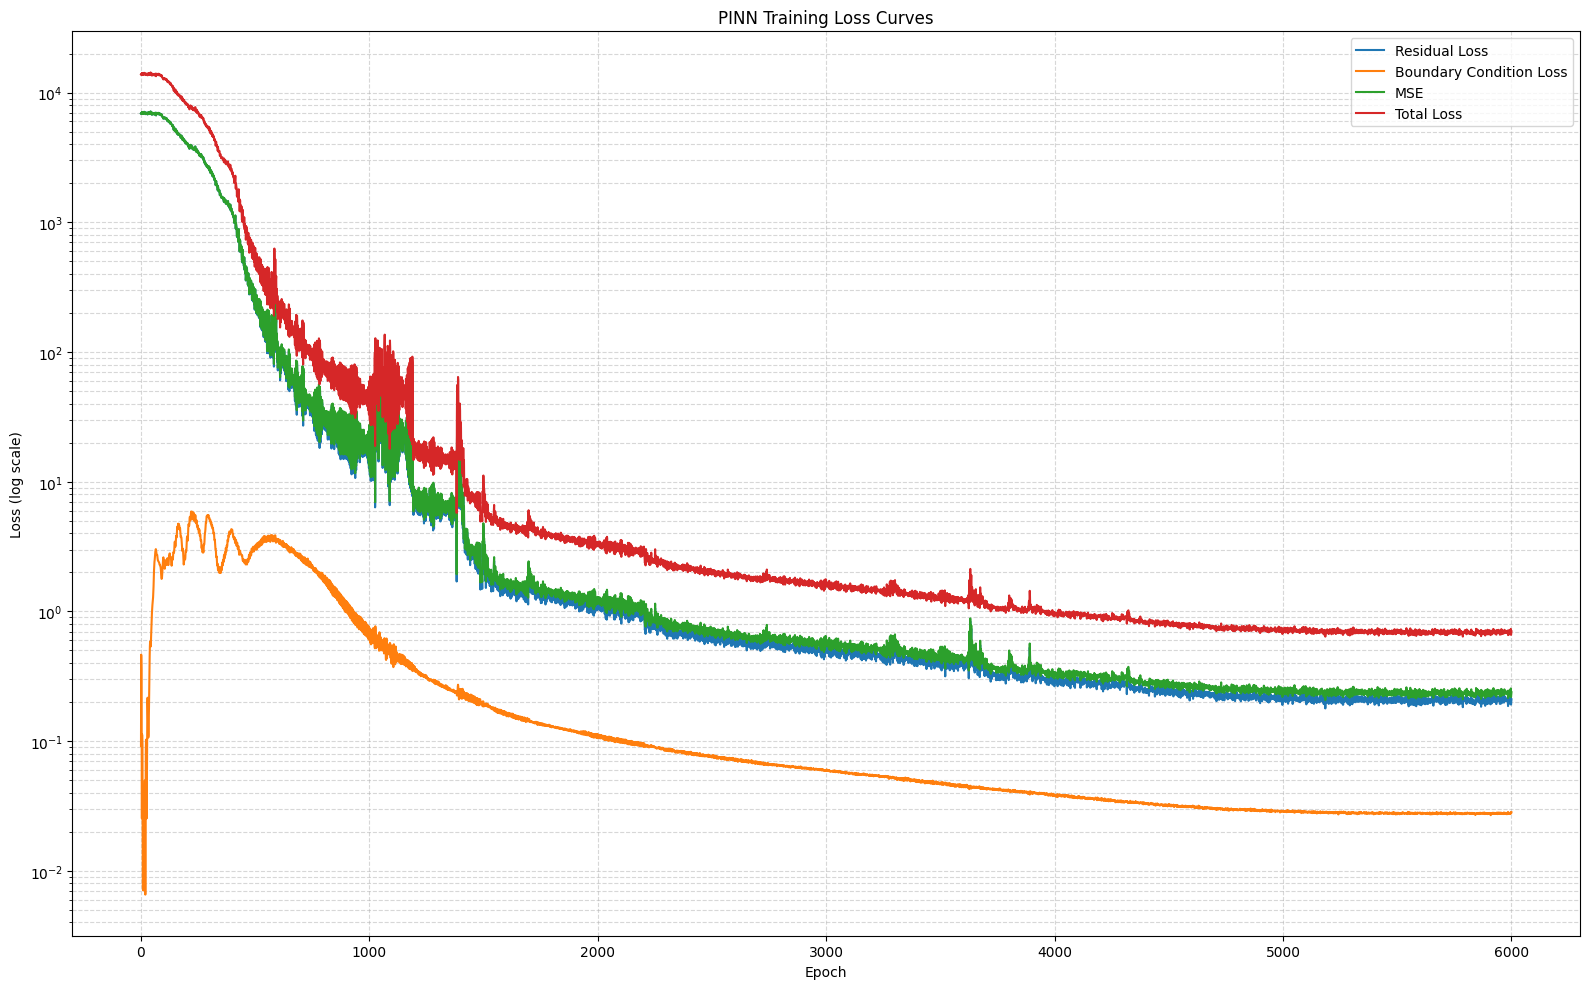

In [69]:
# OPTIONAL: Plotting losses to see how the model progresses throught the training

def plot_losses(history, save_path=None,):

    epochs = range(len(history["total_loss"]))
    
    plt.figure(figsize=(16,10))
    
    # Plot each loss component
    plt.plot(epochs, history["residual_loss"], label="Residual Loss")
    plt.plot(epochs, history["boundary_loss"], label="Boundary Condition Loss")
    plt.plot(epochs, history["mse"], label="MSE")
    plt.plot(epochs, history["total_loss"], label="Total Loss")

    plt.yscale('log')  # Log scale for better visualization of loss dynamics
    plt.xlabel("Epoch")
    plt.ylabel("Loss (log scale)")
    plt.title("PINN Training Loss Curves")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Loss plot saved to: {save_path}")
    
    plt.show()

plot_losses(history=history)